# Análisis Exploratorio Para el Problema de Clasificación (PCOS Diagnosis)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

In [6]:
ds_path = Path("../ml-project/data/raw/dataset_clasification.csv")
data = pd.read_csv(ds_path, sep=",")

pd.set_option("display.max_columns", None)

In [56]:
# Lista de todas las variables del dataset
var_num = data.select_dtypes(include=[np.int64, np.float64]).columns.tolist()
var_cat = data.select_dtypes(include=['string']).columns.tolist()

| Variable | Descripción | Tipo de Dato |
| :--- | :--- | :--- |
| **`Country`** | País de residencia de la paciente (75 países incluidos). | Categórica nominal |
| **`Age`** | Edad de la paciente. | Numérica discreta|
| **`BMI`** | Índice de Masa Corporal categorizado. | Categórica ordinal |
| **`Menstrual Regularity`** | Indica si el ciclo es regular o irregular. | Categórica nominal (binaria) |
| **`Hirsutism`** | Presencia de vello corporal excesivo. | Categórica nominal (binaria) |
| **`Acne Severity`** | Nivel de severidad del acné. | Categórica ordinal (binaria) |
| **`Family History of PCOS`** | Antecedentes de la condición en la familia. | Categórica nominal (binaria) |
| **`Insulin Resistance`** | Presencia de resistencia a la insulina. | Categórica nominal (binaria) |
| **`Lifestyle Score`** | Evaluación de hábitos de vida (dieta, ejercicio, etc.). | Numérica discreta |
| **`Stress Levels`** | Nivel de estrés reportado (Low, Medium, High). | Categórica ordinal |
| **`Urban/Rural`** | Tipo de entorno de vivienda. | Categórica nominal (binaria) |
| **`Socioeconomic Status`** | Nivel de ingresos/estatus social. | Categórica ordinal |
| **`Awareness of PCOS`** | Conocimiento previo de la paciente sobre la enfermedad. | Categórica nominal (binaria) |
| **`Fertility Concerns`** | Si la paciente tiene preocupaciones sobre su fertilidad. | Categórica nominal (binaria) |
| **`Undiagnosed PCOS Likelihood`** | Estimación estadística de probabilidad previa. | Numérica continua |
| **`Ethnicity`** | Grupo étnico de la paciente. | Categórica nominal |
| **`Diagnosis`** | **Variable Objetivo**: Confirmación del diagnóstico. | Categórica nominal (binaria) |

## Histograma de las variables

/tmp/ipykernel_34227/3751816765.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


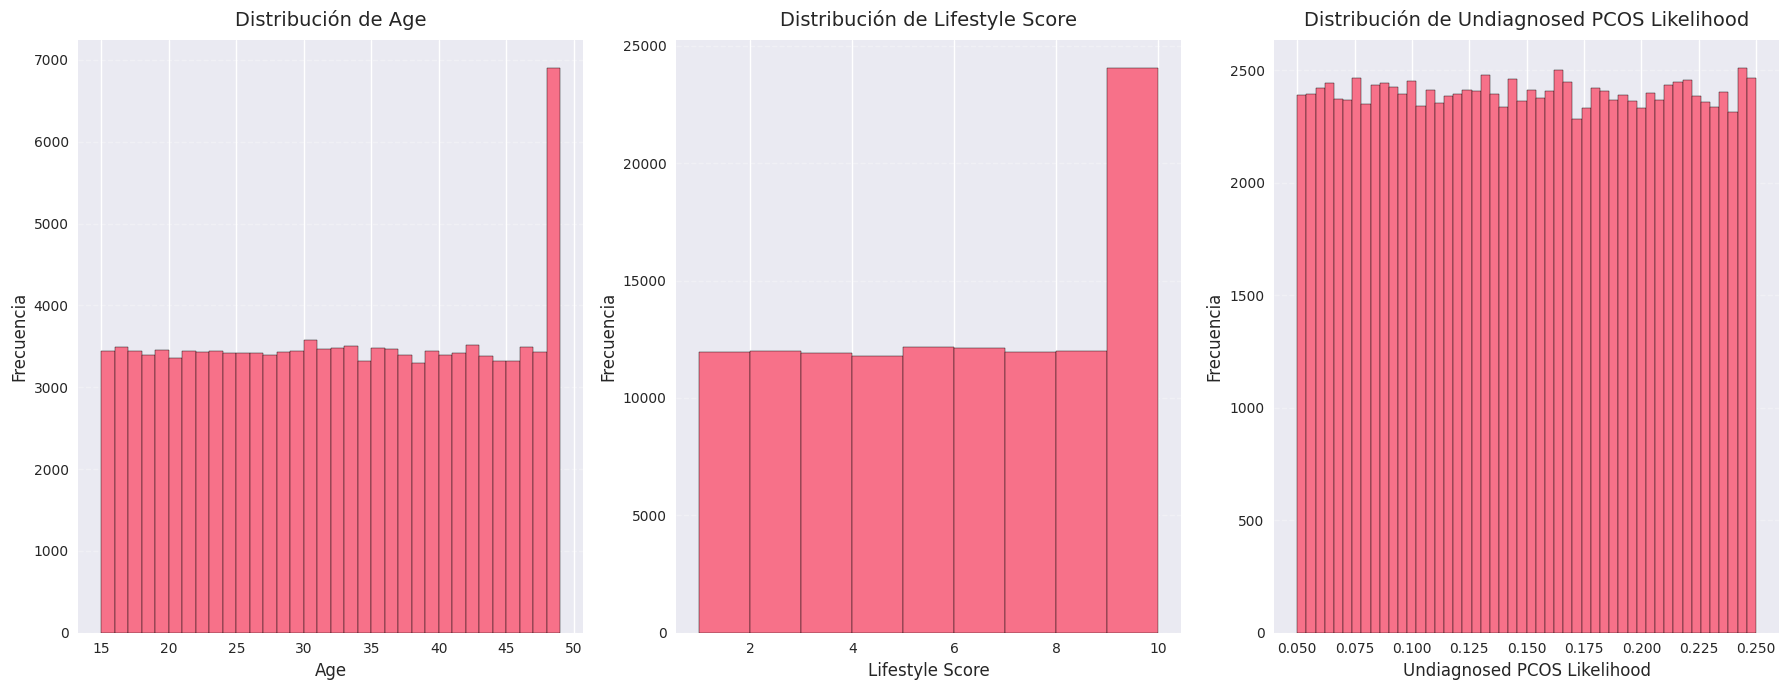

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes = axes.ravel()
colores = ['#4C72B0', '#55A868', '#C44E52']

for i, var in enumerate(var_num):
    valores = data[var].dropna()
    axes[i].hist(valores, bins='auto', alpha=1, edgecolor='black')
    axes[i].legend()
    axes[i].set_title(f"Distribución de {var}", fontsize=14, pad=10)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel("Frecuencia", fontsize=12)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')

sns.despine() if 'sns' in globals() else [ax.spines[side].set_visible(False) for ax in axes for side in ['top', 'right']]
plt.tight_layout()
plt.show()

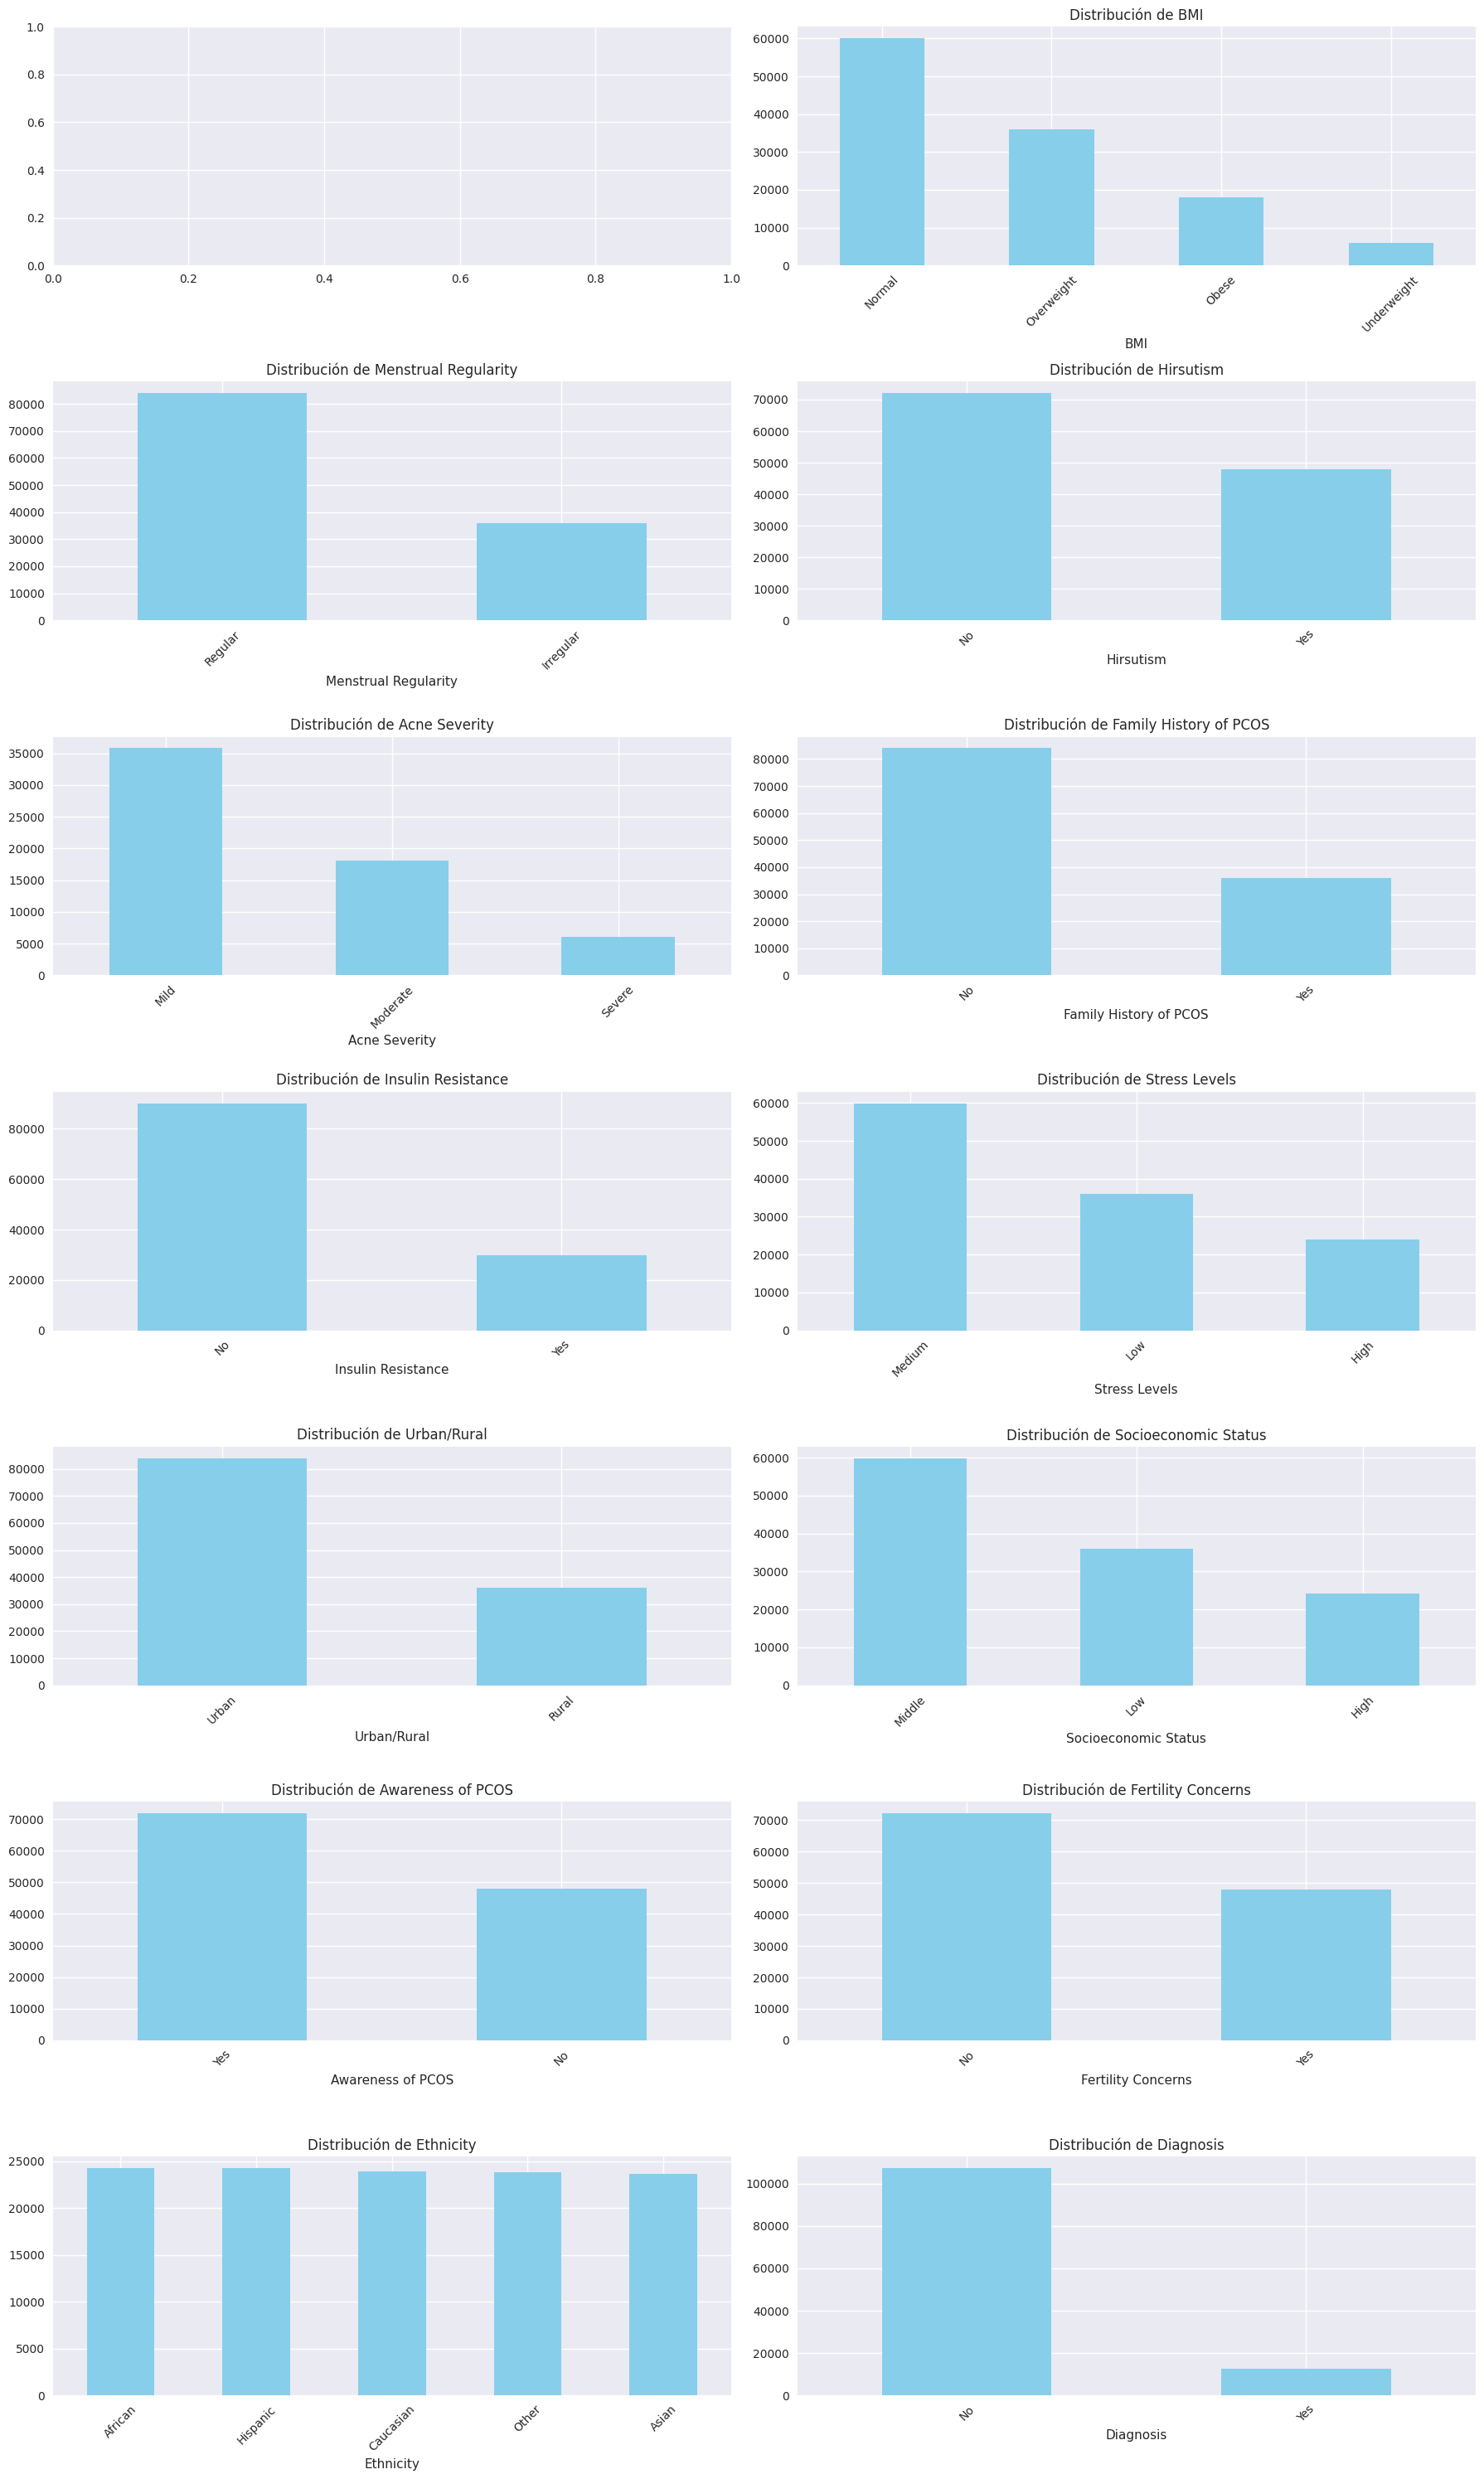

In [79]:
len(var_cat)
fig, axes = plt.subplots(7, 2, figsize=(18, 30))
axes = axes.ravel()

for i, var in enumerate(var_cat):
    if i == 0:
        continue
    data[var].value_counts().plot(kind="bar", ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribución de {var}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Análisis descriptivo

In [ ]:
data[var_num].agg(["mean", "median", "std", "min", "max"])

,Age,Lifestyle Score,Undiagnosed PCOS Likelihood
mean,31.980508,5.506567,0.149937
median,32.000000,6.000000,0.149844
std,10.096799,2.871052,0.057786
min,15.000000,1.000000,0.050001
max,49.000000,10.000000,0.249998
count,120000.000000,120000.000000,120000.000000


In [89]:
data[var_cat].agg(["mode"])

,Country,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Ethnicity,Diagnosis
,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode,mode
0,Burkina Faso,Normal,Regular,No,Mild,No,No,Medium,Urban,Middle,Yes,No,African,No


## Correlación

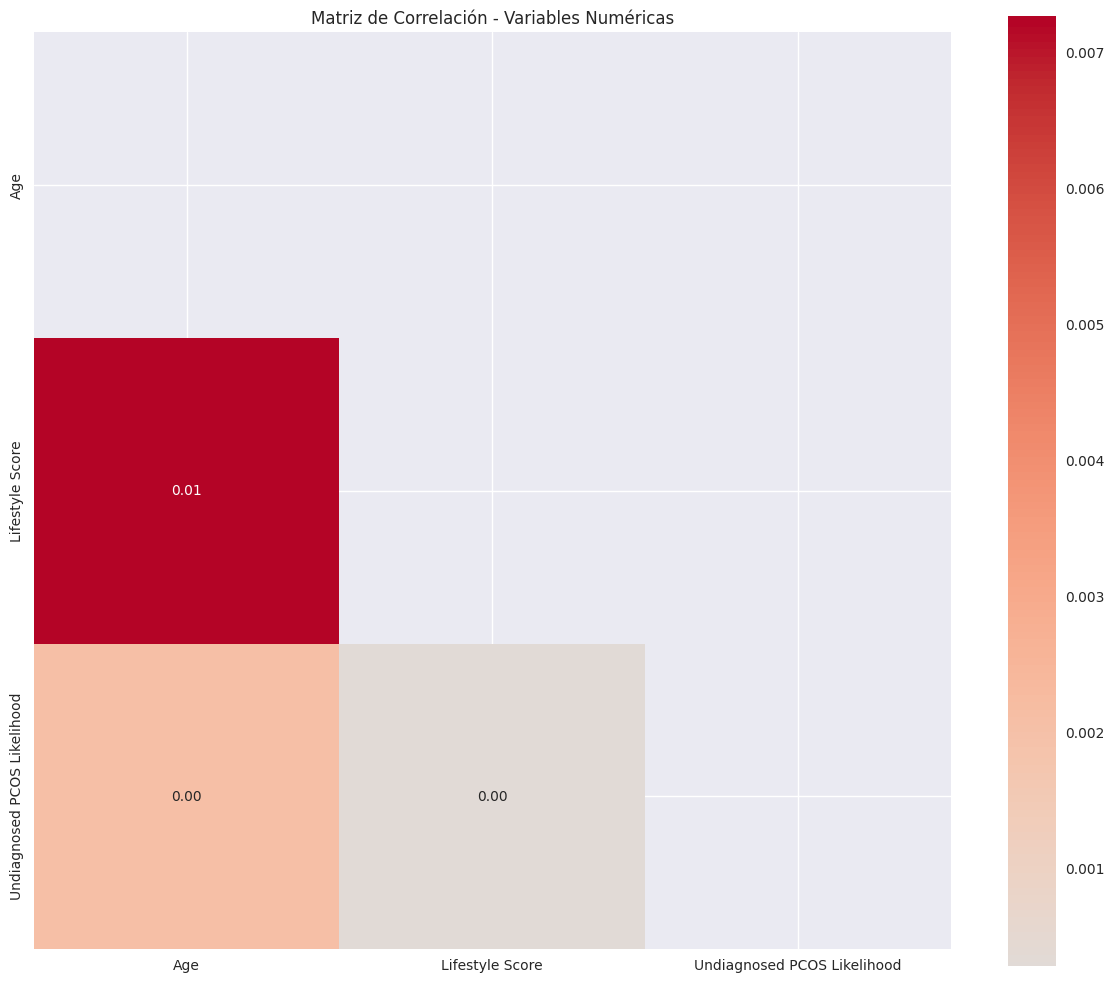

In [90]:
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

## Datos atipicos

In [92]:
# Detección de outliers utilizando el método del IQR
outliers = {}

for col in var_num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers[col])} outliers")

Age: 0 outliers
Lifestyle Score: 0 outliers
Undiagnosed PCOS Likelihood: 0 outliers
